In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..', 'lime_ndt')))
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..')))


In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from lime_ndt.lime_tabular import LimeTabularExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper

# Charger le dataset Ames Housing
data = fetch_openml(name='house_prices', as_frame=True)
X = data.data.select_dtypes(include=[np.number]).dropna(axis=1)  # On garde que les colonnes numériques sans NaN
y = data.target.astype(float)

# Séparer en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Entraîner le modèle global Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Fonction de prédiction globale utilisant le Random Forest
def predict_fn(X):
    return rf.predict(X)

# Créer l'explainer LIME-NDT
explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns,
    discretize_continuous=False,
    mode='regression',
)

# Créer le modèle local NDT
model_regressor = NDTRegressorWrapper(D=X_train.shape[1])

# Expliquer une instance
exp = explainer.explain_instance(
    X_test.values[0],
    predict_fn,
    num_features=34,
    model_regressor=model_regressor
)

print("Explication locale (feature, poids):")
print(exp.as_list())

c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


mean_leaf_values shape: (32, 1, 1)
self.L: 32 self.C: 1
mean_leaf_values shape after squeeze: (32, 1)
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Explication locale (feature, poids):
[('OverallQual', 1214293.8812751991), ('GrLivArea', 410607.93999892275), ('GarageArea', 54779.36671541468), ('1stFlrSF', 52127.18333241093), ('TotalBsmtSF', 47469.81773416711), ('LotArea', 37969.34852867806), ('BsmtFinSF1', 10489.776677556016), ('YearRemodAdd', 6985.633966666661), ('YearBuilt', 6611.793637635565), ('MiscVal', 6185.969895833317), ('OverallCond', 0.0), ('GarageCars', 0.0), ('Fireplaces', 0.0), ('WoodDeckSF', 0.0), ('2ndFlrSF', 0.0), ('MSSubClass', 0.0), ('MoSold', 0.0), ('BsmtHalfBath', 0.0), ('OpenPorchSF', 0.0), ('HalfBath', 0.0), ('BsmtFullBath', 0.0), ('BsmtFinSF2', 0.0), ('BsmtUnfSF', 0.0), ('FullBath', 0.0), ('YrSold', 0.0), ('TotRmsAbvGrd', 0.0), ('KitchenAbvGr', 0.0), ('3SsnPorch', 0.0), ('Id', 0.0), ('BedroomAbvGr', 0.0), ('ScreenPorch', 0.0), ('En

In [4]:
from lime.lime_tabular import LimeTabularExplainer

# Créer l'explainer LIME officiel
explainer_lime = LimeTabularExplainer(
    X_train,
    feature_names=data.feature_names,
    class_names=None,
    discretize_continuous=True,
    mode='regression',
)

# Expliquer une instance avec le modèle local Ridge par défaut de LIME
exp_ridge = explainer_lime.explain_instance(
    X_test[1],
    predict_fn,
    num_features=10
)

print("\nExplication locale avec Ridge (LIME officiel) (feature, poids):")
print(exp_ridge.as_list())

InvalidIndexError: (slice(None, None, None), 0)

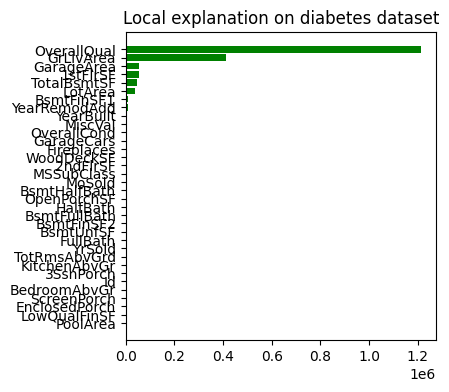

NameError: name 'exp_ridge' is not defined

In [5]:
import matplotlib.pyplot as plt

fig = exp.as_pyplot_figure()
fig.axes[0].set_title("Local explanation on diabetes dataset")
plt.show()

fig_ridge = exp_ridge.as_pyplot_figure()
fig_ridge.axes[0].set_title("Local explanation on diabetes dataset")
plt.show()